# LiDAR Test
I believe that it may be possible to convert LiDAR data directly into a format accessible by base Sionna, without the need for external repositories like NimbusRT

Hopefully my GPU doesn't crash...

2026-01-30 14:15:12.216961: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-30 14:15:12.227607: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1769800512.239877    7128 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1769800512.243324    7128 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1769800512.252303    7128 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

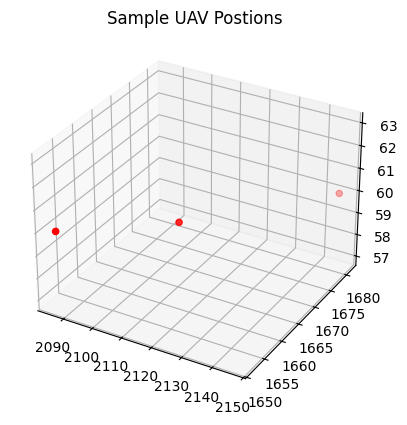

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from AERPAWEnvironment import AERPAWEnv

# Defining the scene, including receivers and transmitters

# Defining a generic UAV for simplicity
generic_uav = {
    "device_type": "tx",
    "mass": 5,
    "efficiency": 0.7,
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([1, 0, 0]),
    "bandwidth": 50,
    "rotor_area": 0.25,
    "signal_power": 3,
    "throughput_capacity": 625000000,
    "battery_capacity": 10000
}

# Configuring some generic uavs with random x and y positions
num_uavs = 3
uavs = []
for i in range(num_uavs):
    uav = dict(generic_uav)
    uav["position"] = np.array([np.random.rand() * 100 + 2050, np.random.rand() * 100 + 1650, 60])
    uavs.append(uav)

# Plotting the positions in 3d
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
plt.title("Sample UAV Postions")
plt.show()

In [2]:
"""
# Defining Generic Ground User

generic_gu = {
    "device_type": "rx",
    "position": np.zeros(3),
    "velocity": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "desired_throughput": 375000
}

# Configuring some sample Ground Users
num_gus = 10
gus = []
for i in range(num_gus):
    gu = dict(generic_gu)
    gu["position"] = np.array([np.random.rand() * 100 - 150, np.random.rand() * 100 + 1750, 100])
    gus.append(gu)

# Plotting UAV and Ground User Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
plt.title("Sample UAV and Ground User Positions")
plt.show()
"""

'\n# Defining Generic Ground User\n\ngeneric_gu = {\n    "device_type": "rx",\n    "position": np.zeros(3),\n    "velocity": np.zeros(3),\n    "color": np.array([0, 1, 0]),\n    "bandwidth": 50,\n    "desired_throughput": 375000\n}\n\n# Configuring some sample Ground Users\nnum_gus = 10\ngus = []\nfor i in range(num_gus):\n    gu = dict(generic_gu)\n    gu["position"] = np.array([np.random.rand() * 100 - 150, np.random.rand() * 100 + 1750, 100])\n    gus.append(gu)\n\n# Plotting UAV and Ground User Positions\nfig = plt.figure()\naxis = fig.add_subplot(projection=\'3d\')\naxis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],\n              [uavs[i]["position"][1] for i in range(num_uavs)],\n              [uavs[i]["position"][2] for i in range(num_uavs)],\n              color="red")\naxis.scatter([gus[i]["position"][0] for i in range(num_gus)],\n           [gus[i]["position"][1] for i in range(num_gus)],\n           [gus[i]["position"][2] for i in range(num_gus)],\n           c

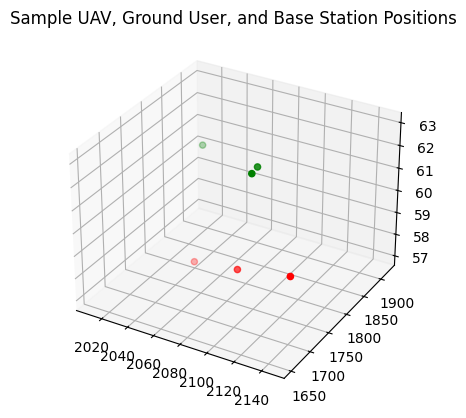

In [3]:
# Generating Sample Base Stations

# Defining a generic base station, then randomizing positions
generic_base_station = {
    "device_type": "rx",
    "position": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "signal_power": 10,
    "throughput_capacity": 625000000,
    "battery_capacity": 1000000
}

# Adding some base stations with random positions
num_bs = 3
bss = []
for i in range(num_bs):
    bs = dict(generic_base_station)
    bs["position"] = np.array([np.random.rand() * 100 + 2000, np.random.rand() * 100 + 1850, 60])
    bss.append(bs)

# Plotting UAV, Ground User, and Base Station Positions
fig = plt.figure()
axis = fig.add_subplot(projection='3d')
axis.scatter([uavs[i]["position"][0] for i in range(num_uavs)],
              [uavs[i]["position"][1] for i in range(num_uavs)],
              [uavs[i]["position"][2] for i in range(num_uavs)],
              color="red")
"""
axis.scatter([gus[i]["position"][0] for i in range(num_gus)],
           [gus[i]["position"][1] for i in range(num_gus)],
           [gus[i]["position"][2] for i in range(num_gus)],
           color="blue")
"""
axis.scatter([bss[i]["position"][0] for i in range(num_bs)],
           [bss[i]["position"][1] for i in range(num_bs)],
           [bss[i]["position"][2] for i in range(num_bs)],
           color="green")
plt.title("Sample UAV, Ground User, and Base Station Positions")
plt.show()

In [7]:
# test_env = AERPAWEnv(scene_path="../data/aerpaw/LakeWheelerTerrain25/lake_wheeler_road_aerpaw.xml",
#                      uavs={}, ground_users={}, base_stations={}, temperature=300)

# Creating the scene with the sample devices
env = AERPAWEnv(scene_path='/home/everetttucker471/Documents/RL-AERPAW-DT/LiDAR/meshes-01-30/lake-wheeler-trees-segmented.xml',
                uavs=uavs, ground_users={}, base_stations=bss, temperature=300)
env.visualize()

# env = AERPAWEnv(scene_path='../data/aerpaw/LakeWheelerTerrain/lake_wheeler_road_aerpaw.xml',
#                 uavs={}, ground_users={}, base_stations={}, temperature=300)

2026-01-30 14:18:30 WARN wrk2 [PLYMesh] "building-mesh-output.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.

2026-01-30 14:18:30 WARN wrk7 [PLYMesh] "terrain-mesh-small-output.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.

2026-01-30 14:18:30 WARN wrk2 [PLYMesh] "building-mesh-output.ply": Mesh attribute "vertex_color" has integer fields: color attributes are expected to be in the [0, 1] range.

2026-01-30 14:18:35 WARN wrk7 [PLYMesh] "terrain-mesh-small-output.ply": Mesh attribute "vertex_color" has integer fields: color attributes are expected to be in the [0, 1] range.

In [5]:
# Computing some sample paths to test the geometry of the environment, does it actually work?
import time
import drjit as dr

dr.flush_malloc_cache()
start = time.time()
snr_dict = env.getSNR(max_depth=3, num_samples=10000000, sampling_frequency=1.0, )  # Using default arguments, should be alright
end = time.time()
print(f"Time to compute SNR: {end - start}")
print(f"Number of Recievers: {len(snr_dict)}")
print(f"Number of Transmitters: {len(snr_dict["bs0"])}")
print(snr_dict["bs0"])

Time to compute SNR: 0.4063413143157959
Number of Recievers: 3
Number of Transmitters: 3
{'uav0': -2.501252398266178, 'uav1': -0.32978560937420165, 'uav2': 0.9471820921562972}


I0000 00:00:1769800519.453692    7128 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 849 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [6]:
# Visualizing paths, this is the real test to see if rays bounce off the geometry of the environment
general_paths = env.computeGeneralPaths(max_depth=2, num_samples=50000, mode='gpu')
env.visualize(paths=general_paths)

In [11]:
radio_map = env.computeRadioMap(max_depth=2, num_samples=1000000, cell_size=(5.0, 5.0))
env.visualize(radio_map=radio_map)

In [1]:
# Imports
import numpy as np;
import drjit as dr;
import matplotlib.pyplot as plt;
from AERPAWEnvironment import AERPAWEnv;

2025-12-05 14:19:42.071939: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-05 14:19:42.082696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764962382.095904   19958 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764962382.100009   19958 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764962382.110221   19958 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [14]:
# Importing some more realistic transmitters and receivers for this scenario

center = np.array([-200, -450, 300])
uavs = []
num_uavs = 5

for i in range(num_uavs):
    uavs.append({
    "device_type": "tx",
    "mass": 5,
    "efficiency": 0.7,
    "position": center + np.random.rand(3) * 50,
    "velocity": np.zeros(3),
    "color": np.array([1, 0, 0]),
    "bandwidth": 50,
    "rotor_area": 0.25,
    "signal_power": 3,
    "throughput_capacity": 625000000,
    "battery_capacity": 10000
})
    
gus = []
num_gu = 10
for i in range(num_gu):
    gus.append({
    "device_type": "rx",
    "position": center + np.random.rand(3) * 60 - np.array([-200, 200, 20]),
    "velocity": np.zeros(3),
    "color": np.array([0, 1, 0]),
    "bandwidth": 50,
    "desired_throughput": 375000
})
    
# Creating the scene with the sample devices
env = AERPAWEnv(scene_path='../data/LiDAR/lidar-sample.xml',
                uavs=uavs, ground_users=gus, base_stations={}, temperature=300)

env.visualize()

2025-12-05 14:29:09 WARN main [PLYMesh] "translated-mesh-ascii-works.ply": performance warning -- this file uses the ASCII PLY format, which is slow to parse. Consider converting it to the binary PLY format.

In [19]:
# Computing some sample paths to test the geometry of the environment, does it actually work?
import time

start = time.time()
snr_dict = env.getSNR(max_depth=2, num_samples=5000000, sampling_frequency=1.0, )  # Using default arguments, should be alright
end = time.time()
print(f"Time to compute SNR: {end - start} seconds")
print(f"Number of Recievers: {len(snr_dict)}")
print(f"Number of Transmitters: {len(snr_dict["gu0"])}")
print(snr_dict["gu0"])

Time to compute SNR: 0.3788776397705078 seconds
Number of Recievers: 10
Number of Transmitters: 5
{'uav0': 15.947327440048229, 'uav1': 1.4191239421156103, 'uav2': 16.512164584557123, 'uav3': 19.716808784951454, 'uav4': -0.9005608993866505}


In [16]:
# Visualizing paths, this is the real test to see if ray bounce off the geometry of the environment
dr.flush_malloc_cache()  # To free memory for repeated runs
general_paths = env.computeGeneralPaths(max_depth=2, num_samples=1000000, mode='gpu')
env.visualize(paths=general_paths)

In [5]:
from sionna.rt import PathSolver

dr.flush_malloc_cache()  # To free memory for repeated runs
p_solver  = PathSolver()

# Computing paths with scene transmitters and receivers, and specified parameters
paths = p_solver(scene=env.scene,
                 max_depth=2,
                 los=True,
                 specular_reflection=True,
                 diffuse_reflection=False,
                 refraction=True,
                 synthetic_array=False,
                 seed=41)

env.visualize(paths=paths)

# Getting the Channel Impulse response
print(paths.cir())

([[[[[[[1.51412e-06],
     [-2.03142e-07],
     [0]]],
   [[[-2.19672e-07],
     [0],
     [0]]],
   [[[-2.29628e-07],
     [0],
     [0]]],
   [[[-1.60166e-07],
     [0],
     [0]]],
   [[[-3.01828e-07],
     [0],
     [0]]]]],
 [[[[[-2.91997e-07],
     [0],
     [0]]],
   [[[7.78006e-06],
     [-3.29112e-07],
     [0]]],
   [[[-3.40746e-07],
     [0],
     [0]]],
   [[[-1.46356e-07],
     [0],
     [0]]],
   [[[-4.09774e-07],
     [0],
     [0]]]]],
 [[[[[3.70309e-06],
     [4.90636e-06],
     [-2.43856e-07]]],
   [[[-2.69068e-07],
     [0],
     [0]]],
   [[[3.08967e-06],
     [-2.8006e-07],
     [0]]],
   [[[-1.52211e-07],
     [0],
     [0]]],
   [[[-3.52809e-07],
     [0],
     [0]]]]],
 [[[[[-6.87428e-07],
     [0],
     [0]]],
   [[[6.97743e-06],
     [-8.40764e-07],
     [0]]],
   [[[2.04151e-06],
     [-8.69956e-07],
     [0]]],
   [[[-2.74321e-07],
     [2.25584e-06],
     [2.29483e-06]]],
   [[[-9.86373e-07],
     [0],
     [0]]]]],
 [[[[[-2.73139e-07],
     [0],
     [0]]]